

## 과제 목적
이번 과제는 수업에서 다룬 **Grain, Cardinality, JOIN, CTE, Window Function, 파생변수**를 실제 Olist 데이터에 직접 적용하는 것을 목표로 합니다. 단순히 SQL이 실행되는지 확인하는 것이 아니라, **결과가 분석적으로 올바른지 직접 검증하고 그 의미를 해석**해야 합니다. 생성형 AI를 사용할 수 있지만, AI가 제안한 쿼리나 해석을 그대로 제출하는 것이 아니라 **본인의 로컬 DB에서 실행 결과를 확인하고, 지표 정의와 JOIN 구조가 타당한지 판단**해야 합니다. 최종적으로 Colab에서 수행한 실험·그래프·해석을 기술블로그에 재구성합니다.

---
> 블로그에는 코드를 그대로 복사하기보다 **왜 이 쿼리를 썼는지 → 어떻게 검증했는지 → 결과를 어떻게 해석했는지**를 중심으로 작성하세요.



# 0. 환경 설정

일반 Colab Hosted Runtime의 `127.0.0.1`은 본인 PC가 아닙니다.  
로컬 MySQL에 접속하려면 **Colab Local Runtime**을 사용하세요.

로컬 터미널/PowerShell에서 Jupyter를 실행한 뒤 Colab의  
**연결 → 로컬 런타임에 연결** 메뉴에 URL을 입력합니다.

```bash
jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True
```


In [1]:
%pip install -q pymysql sqlalchemy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [1]:
from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd
import matplotlib.pyplot as plt

DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "olist_sql_session"

DB_USER = input("MySQL 사용자명: ").strip()
DB_PASSWORD = getpass("MySQL 비밀번호: ")

url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"},
)

engine = create_engine(url, pool_pre_ping=True)

def run_sql(sql: str) -> pd.DataFrame:
    """SELECT / WITH 쿼리를 실행하고 DataFrame으로 반환합니다."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("DB 연결 객체 생성 완료")


MySQL 사용자명: root
MySQL 비밀번호: ··········
DB 연결 객체 생성 완료


In [2]:
with engine.connect() as conn:
    info = conn.execute(
        text("SELECT VERSION() AS mysql_version, DATABASE() AS current_db;")
    ).mappings().one()

print(dict(info))
print("✅ 연결 성공")


{'mysql_version': '8.0.45', 'current_db': 'olist_sql_session'}
✅ 연결 성공


In [3]:
run_sql("SHOW TABLES;")


,Tables_in_olist_sql_session
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,order_mart
9,product_category_name_translation


# 1. 필수 과제

## 빈칸 작성 방식
- `__BLANK_n__` 부분만 올바른 SQL/Python 코드로 바꾸면 됩니다.
- 빈칸을 채워 실행한 뒤  **결과 검증 + 해석**까지 작성하세요.


## 1.1 Grain과 Cardinality 확인

세 테이블의 **한 행이 무엇을 의미하는지** 확인합니다.

- `olist_orders_dataset`
- `olist_order_items_dataset`
- `olist_order_payments_dataset`

### 목표
- 전체 행 수
- 고유 주문 수
- 한 주문이 여러 행으로 나타나는지 확인


In [4]:
# [1.1-A] orders
# 힌트: 고유 주문 수는 order_id에 DISTINCT를 적용합니다.

orders_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_orders_dataset;
"""

orders_grain_df = run_sql(orders_grain_sql)
orders_grain_df


,total_rows,distinct_orders
0,99441,99441


In [5]:
# [1.1-B] order_items
# 힌트: 한 주문 안에 여러 상품 행이 있을 수 있습니다.
# 전체 행 수와 고유 order_id 수의 차이를 확인하세요.

items_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_items_dataset;
"""

items_grain_df = run_sql(items_grain_sql)
items_grain_df


,total_rows,distinct_orders
0,112650,98666


In [6]:
# [1.1-C] payments
# 힌트: 한 주문에 결제 행이 여러 개 존재할 수 있습니다.

payments_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_payments_dataset;
"""

payments_grain_df = run_sql(payments_grain_sql)
payments_grain_df


,total_rows,distinct_orders
0,103886,99440


### 1.1 해석
- `orders`의 한 행: 1개의 고유한 주문 (총 99,441행 / 고유 주문 99,441건)
- `order_items`의 한 행: 1개의 주문에 포함된 개별 상품 (총 112,650행 / 고유 주문 98,666건)
- `payments`의 한 행: 1개의 주문에 사용된 개별 결제 수단/내역 (총 103,886행 / 고유 주문 99,440건)
- `orders → order_items` 관계: 1:N(일대다) 관계. 하나의 주문 번호에 여러 개의 상품이 존재할 수 있다.
- `orders → payments` 관계: 1:N(일대다) 관계. 하나의 주문 번호에 여러 번의 결제 시도나 복합 결제(카드+포인트 등)가 존재할 수 있다.
- Grain을 확인하지 않고 JOIN하면 어떤 문제가 생길 수 있는지: 데이터 Fan-out 현상이 발생할 수 있다. `orders` 테이블(1)에 1:N 관계인 테이블을 단순히 JOIN하면 1건의 주문행이 N건으로 중복 복제된다. 이 상태에서 총 주문 수나 매출액을 집계(SUM/COUNT)하면 값이 실제보다 과대 계산되는 오류가 생긴다.


---

## 1.2 문법적으로 맞는 JOIN이 왜 잘못된 결과를 만들까?

배송 완료(`delivered`) 주문을 기준으로:
1. 주문 수
2. 상품 판매금액
3. 결제금액

을 먼저 **올바른 기준값**으로 계산한 뒤,  
`orders + order_items + payments`를 한 번에 JOIN한 결과와 비교합니다.


In [7]:
# [1.2-A] 올바른 기준값 계산
#
# 힌트
# - 주문 수: orders 단독
# - 상품 판매금액: orders + order_items만 JOIN
# - 결제금액: orders + payments만 JOIN
# - 세 지표 모두 delivered 주문만 사용
#
# 문자열 delivered는 따옴표를 포함해야 합니다.

correct_metric_sql = """
SELECT
    (
        SELECT COUNT(*)
        FROM olist_orders_dataset
        WHERE order_status = "delivered"
    ) AS correct_order_count,

    (
        SELECT ROUND(SUM(oi.price), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_items_dataset AS oi
          ON o.order_id = oi.order_id
        WHERE o.order_status = "delivered"
    ) AS correct_item_amount,

    (
        SELECT ROUND(SUM(p.payment_value), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_payments_dataset AS p
          ON o.order_id = p.order_id
        WHERE o.order_status = "delivered"
    ) AS correct_payment_amount;
"""

correct_df = run_sql(correct_metric_sql)
correct_df


,correct_order_count,correct_item_amount,correct_payment_amount
0,96478,13221498.11,15422461.77


In [8]:
# [1.2-B] naive JOIN
#
# 힌트
# - orders ↔ order_items: order_id
# - orders ↔ payments: order_id
# - delivered 주문만 필터링
# - COUNT(*)는 JOIN된 결과 행 수
# - COUNT(DISTINCT o.order_id)는 JOIN 뒤 고유 주문 수

naive_join_sql = """
SELECT
    COUNT(*) AS joined_rows,
    COUNT(DISTINCT o.order_id) AS orders_after_join,
    ROUND(SUM(oi.price), 2) AS wrong_item_amount,
    ROUND(SUM(p.payment_value), 2) AS wrong_payment_amount
FROM olist_orders_dataset AS o
JOIN olist_order_items_dataset AS oi
  ON o.order_id = oi.order_id
JOIN olist_order_payments_dataset AS p
  ON o.order_id = p.order_id
WHERE o.order_status = "delivered";
"""

naive_df = run_sql(naive_join_sql)
naive_df


,joined_rows,orders_after_join,wrong_item_amount,wrong_payment_amount
0,115035,96477,13813828.71,19776160.44


In [9]:
# [1.2-C] 금액 부풀림 비율
#
# 공식:
# (잘못 계산된 값 / 올바른 기준값 - 1) * 100

correct_item = float(correct_df.loc[0, "correct_item_amount"])
correct_payment = float(correct_df.loc[0, "correct_payment_amount"])
wrong_item = float(naive_df.loc[0, "wrong_item_amount"])
wrong_payment = float(naive_df.loc[0, "wrong_payment_amount"])

item_inflation_pct = (wrong_item / correct_item - 1) * 100
payment_inflation_pct = (wrong_payment / correct_payment - 1) * 100

print(f"상품 판매금액 증가율: {item_inflation_pct:.2f}%")
print(f"결제금액 증가율: {payment_inflation_pct:.2f}%")


상품 판매금액 증가율: 4.48%
결제금액 증가율: 28.23%


### 1.2 해석
1. JOIN 후 행 수가 주문 수보다 증가한 이유는?

`orders`(1) 테이블에 `order_items`(N)와 `payments`(M)라는 두 개의 1:N 관계 테이블을 조건 없이 다중 JOIN 했기 때문이다. 그 결과 1건의 주문이 (상품 수 * 결제 건수)만큼 중복 복제되는 Fan-out 현상이 발생했다.

2. `COUNT(*)`와 `COUNT(DISTINCT o.order_id)`가 다른 이유는?

`COUNT(*)`는 JOIN 과정에서 부풀려진 모든 교차 행의 총합(115,035행)을 그대로 집계하였다. 그러나 `COUNT(DISTINCT o.order_id)`는 부풀려진 데이터에서 고유한 주문 번호의 개수(96,477건)만을 뽑아내서 집계했기 때문에 두 값이 다르게 나타난다.

3. 상품 판매금액과 결제금액 중 어느 쪽이 더 크게 부풀었는가?

상품 판매금액 증가율: 4.48%, 결제금액 증가율: 28.23%이므로 결제금액이 더 크게 부풀었다.

4. `SELECT DISTINCT`만으로 이 문제를 해결하면 안 되는 이유는?

`DISTINCT`는 행을 구성하는 모든 컬럼의 값이 완전히 일치할 때만 중복을 제거한다. JOIN된 결과는 상품 정보나 결제 수단 등 세부 값이 하나라도 다르기 때문에 고유한 행으로 취급되어 `SUM`을 할 때 부풀려진 금액이 그대로 합산된다. 근본적인 해결책이 아니며 집계 전 서브쿼리나 CTE로 미리 단위를 맞추는 것이 좋다.

5. JOIN 결과의 **한 행**은 무엇을 의미하게 되었는가?

1건의 주문이나 1건의 상품 중 그 무엇도 의미하지 않는다. '특정 주문에 속한 1개의 개별 상품과 1개의 개별 결제 수단이 무작위로 교차된 조합(Combination)을 의미한다.

**① 관계대수 측면의 오류**:
`order_items`와 `payments`는 서로 직접적인 연관성이 없는 독립적인 entity이다. 이를 하나의 쿼리에서 부모키 `order_id`만으로 JOIN하면, 해당 키를 가진 파티션 내에서 튜플 간의 무조건적인 교차 결합(Cross Join)이 발생한다. 즉 상품의 Cardinality를 M, 결제 수단의 Cardinality를 N이라 할 때, 1개의 부모 행에 대해 M*N 개의 행이 강제로 증식된다.

**② Data Grain의 훼손**:
데이터베이스에서 정상적인 튜플은 원자성을 가진 실제 단일 건을 나타내야 한다. 하지만 이 다중 JOIN으로 도출된 행은 특정 상품 인스턴스와 특정 결제 인스턴스의 임의적인 논리적 순열일 뿐, 실제 로직과 트랜잭션 상에서는 발생한 적이 없는 허수이다.

**③ 통계적 편향의 발생**:
통계학적 관점에서 이는 단일 관측치의 비정상적인 중복 표집과 같다. 모집단의 실제 발생 사건이 아닌 연산의 논리적 결함으로 증식된 튜플을 바탕으로 집계함수(`SUM`, `COUNT`)를 적용하면, 특정 종속 변수의 값이 교차 결합 횟수만큼 과대 가중되어 최종 추정량에 상향 편향을 초래한다.


---

## 1.3 주문 단위 분석 데이터 구성 + 배송 지연과 리뷰 분석

Mission 1의 Row Explosion을 피하기 위해 각 1:N 테이블을 **order_id 단위로 먼저 집계**합니다.

목표 Grain:

> **1 row = 1 order**

### 파생변수
- `delivery_days`: 실제 배송완료일 - 주문일
- `delay_days`: 실제 배송완료일 - 예상 배송일
- `is_delayed`: 실제 배송완료일이 예상 배송일보다 늦으면 1


In [10]:
# [1.3-A] 주문 단위 Mart 만들기
#
# item_summary 힌트
# - product_count: product_id의 고유 개수
# - seller_count: seller_id의 고유 개수
# - item_amount: price 합계
# - freight_amount: freight_value 합계
#
# payment_summary 힌트
# - payment_amount: payment_value 합계
# - max_installments: payment_installments 최대값
#
# review_summary 힌트
# - avg_review_score: review_score 평균
#
# 각 CTE의 GROUP BY 기준은 모두 order_id 입니다.

order_mart_sql = """
WITH item_summary AS (
    SELECT
        order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT product_id) AS product_count,
        COUNT(DISTINCT seller_id) AS seller_count,
        SUM(price) AS item_amount,
        SUM(freight_value) AS freight_amount
    FROM olist_order_items_dataset
    GROUP BY order_id
),

payment_summary AS (
    SELECT
        order_id,
        COUNT(*) AS payment_count,
        SUM(payment_value) AS payment_amount,
        MAX(payment_installments) AS max_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        COUNT(*) AS review_count,
        AVG(review_score) AS avg_review_score
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    i.item_count,
    i.product_count,
    i.seller_count,
    i.item_amount,
    i.freight_amount,

    p.payment_count,
    p.payment_amount,
    p.max_installments,

    r.review_count,
    r.avg_review_score,

    /* delivery_days = 실제 배송완료일 - 주문일 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp
        )
    END AS delivery_days,

    /* delay_days = 실제 배송완료일 - 예상 배송일
       양수: 지연 / 0: 예정일 / 음수: 조기 배송 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        )
    END AS delay_days,

    /* 실제 배송완료일 > 예상 배송일 이면 1 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) > 0 THEN 1
        ELSE 0
    END AS is_delayed

FROM olist_orders_dataset AS o

LEFT JOIN olist_customers_dataset AS c
  ON o.customer_id = c.customer_id

LEFT JOIN item_summary AS i
  ON o.order_id = i.order_id

LEFT JOIN payment_summary AS p
  ON o.order_id = p.order_id

LEFT JOIN review_summary AS r
  ON o.order_id = r.order_id;
"""

order_mart_df = run_sql(order_mart_sql)
order_mart_df.head()


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_count,product_count,...,item_amount,freight_amount,payment_count,payment_amount,max_installments,review_count,avg_review_score,delivery_days,delay_days,is_delayed
0,05ddf4cc62efcc6f34b8c693eaa2db01,b77ee5671feb9b6efce84cc804842024,5c64fc047d4115cc4be24c9c0c9503c2,DF,delivered,2018-07-03 18:18:34,2018-07-09 16:34:28,2018-07-25,1.0,1.0,...,69.99,18.59,1.0,88.58,4.0,1.0,5.0,6.0,-16.0,0.0
1,0bfa8870838091fe8171ed69f6b89fee,10f2beaf4d0f6f475d9f4cfdc9b05457,84a7bab3a01dd7085bf2b17082e6c8a4,SP,delivered,2018-08-22 10:21:13,2018-08-24 22:41:52,2018-08-28,2.0,1.0,...,49.98,14.88,1.0,64.86,1.0,1.0,5.0,2.0,-4.0,0.0
2,20f136d890c31a62486c809f91a5b098,e46db370a98dec564da620109436f09a,127d41455fd0ee4fe94ecd34b6b206b9,MG,delivered,2017-06-21 16:54:28,2017-07-03 14:39:54,2017-07-13,1.0,1.0,...,69.90,47.78,1.0,117.68,10.0,1.0,4.0,12.0,-10.0,0.0
3,22561cc73693742c65f9e31bd0e8df08,93e314b682a2da481b45a81ccdf91ef2,3e3bca450eb65febb63301472b833f4b,RJ,delivered,2017-05-23 08:58:15,2017-06-12 17:13:22,2017-06-21,1.0,1.0,...,387.49,17.46,1.0,404.95,10.0,1.0,5.0,20.0,-9.0,0.0
4,25e8002575a945e8d4ae84ca208daa50,e8ab8f389636432382f031e90d3606bb,42832ed9903e18991afc347bb4c28dac,SP,delivered,2018-06-18 07:49:22,2018-06-22 15:45:51,2018-07-05,1.0,1.0,...,79.90,24.17,1.0,104.07,1.0,1.0,4.0,4.0,-13.0,0.0


In [11]:
# [1.3-B] Grain 검증
#
# 목표: len(order_mart_df) == order_id 고유 개수
# 즉, 1 row = 1 order가 되어야 합니다.

total_rows = len(order_mart_df)
unique_orders = order_mart_df["order_id"].nunique()

print("전체 행 수:", total_rows)
print("고유 주문 수:", unique_orders)

assert total_rows == unique_orders


전체 행 수: 99441
고유 주문 수: 99441


In [12]:
# [1.3-C] 배송 상태별 리뷰 점수 비교
#
# 이번 단계는 SQL을 다시 길게 쓰기보다,
# 위에서 생성한 주문 단위 DataFrame을 이용해도 됩니다.
#
# 힌트
# - delivered 주문만 남기기
# - is_delayed, avg_review_score가 NULL인 행 제거
# - is_delayed 0 -> on_time / 1 -> delayed
# - delivery_status 기준 groupby
# - 평균 리뷰, 평균 배송일, 평균 지연일 계산

delivery_analysis_df = order_mart_df[
    (order_mart_df["order_status"] == "delivered")
    & order_mart_df["is_delayed"].notna()
    & order_mart_df["avg_review_score"].notna()
].copy()

delivery_analysis_df["delivery_status"] = delivery_analysis_df["is_delayed"].map(
    {0: "on_time", 1: "delayed"}
)

delivery_review_df = (
    delivery_analysis_df
    .groupby("delivery_status", as_index=False)
    .agg(
        order_count=("order_id", "count"), #주문 수 집계
        avg_review_score=("avg_review_score", "mean"), #리뷰 점수 평균 집계
        avg_delivery_days=("delivery_days", "mean"), #배송일 평균 집계
        avg_delay_days=("delay_days", "mean") #지연일 평균 집계
    )
)

delivery_review_df


,delivery_status,order_count,avg_review_score,avg_delivery_days,avg_delay_days
0,delayed,6381,2.271823,33.784360,10.518414
1,on_time,89443,4.290589,10.933701,-13.513366


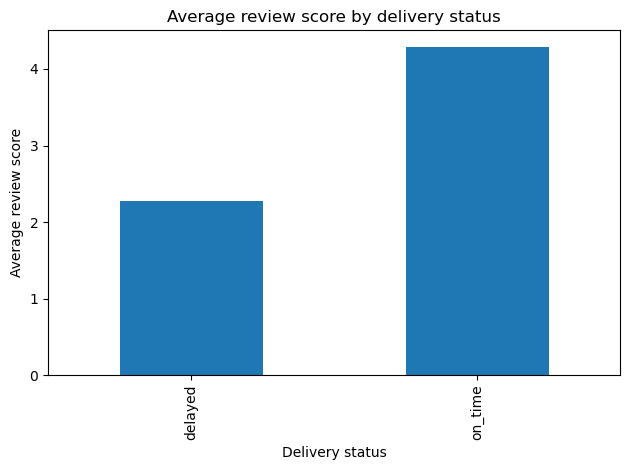

In [13]:
# [1.3-D] 시각화
#
# 힌트
# - kind = "bar"
# - x = "delivery_status"
# - y = "avg_review_score"

ax = delivery_review_df.plot(
    kind="bar",
    x="delivery_status",
    y="avg_review_score",
    legend=False
)

ax.set_title("Average review score by delivery status")
ax.set_xlabel("Delivery status")
ax.set_ylabel("Average review score")
plt.tight_layout()
plt.show()


### 1.3 해석
1. 정상 배송과 지연 배송의 평균 리뷰 점수는 어떻게 달랐는가?

정상 배송 `on_time` 주문의 평균 리뷰 점수는 4.29점인 반면, 지연 배송 `delayed` 주문은 2.27점이었다. 시각화 그래프에서도 확인할 수 있듯이, 배송이 지연될 경우 고객 만족도가 약 2점 하락하는 것을 볼 수 있다.

2. `delay_days`와 `is_delayed`를 둘 다 만든 이유는?

분석 목적에 맞게 활용도를 극대화하기 위함이다.

- `is_delayed`(범주형 변수): 지연 여부(O/X)를 기준으로 두 집단 간의 성과를 직관적으로 비교하고 시각화하기 좋다.

- `delay_days`(연속형 변수): 지연 여부뿐만 아니라 며칠이나 늦었을 때 점수가 하락하는지 심층적인 상관관계를 분석할 때 필요하다.

3. `order_mart`의 Grain은?

1행=1건의 고유한 주문 `order_id`이다. 앞서 CTE를 통해 `items`, `payments`, `reviews` 테이블을 `order_id` 기준으로 각각 1:1 요약한 뒤 원본 주문 테이블과 병합했으므로 더 이상 데이터가 부풀려지는 Fan-out 현상 없이 깔끔하게 Grain이 유지되었다.

4. 이 결과만으로 배송 지연이 리뷰 하락의 **원인**이라고 말할 수 있는가?

아니다. 강한 상관관계는 확인했지만 이것이 인과관계를 의미하지는 않는다. 부피가 큰 화물 배송이라 원래 배송이 늦는 상품(가구 등)이 파손 등 다른 이유로 점수가 낮았을 수도 있고, 특정 지역의 택배 파업이 겹쳤을 수도 있다. (교란 변수의 존재 가능성)

5. 추가로 확인하고 싶은 변수는?

명확한 원인을 찾기 위해 다음의 부분을 확인해볼 수 있다.

- 지연 일수(`delay_days`)별 리뷰 하락폭: 하루만 늦어도 1점을 주는지 3일 이상 늦었을 때부터 하락하는지 임계점 확인

- 카테고리: 배송 지연에 유독 민감한 상품군(예; 신선식품, 선물용품)이 따로 있는지 파악

- 판매자(`seller_id`): 배송 지연과 악성 리뷰가 전체 시스템 문제인지 특정 악성 판매자들에게 몰려있는지 확인

- 상품 가격(`item_amount`): 고가 상품을 산 고객일수록 배송 지연에 더 엄격한지 확인



---

## 1.4 재구매 고객은 몇 명인가? — 지표 정의 비교

### 정의 A
모든 주문을 구매로 간주

### 정의 B
`delivered` 주문만 성공한 구매로 간주

### 핵심
- 실제 고객 식별자: `customer_unique_id`
- 고객별 주문 순서: `ROW_NUMBER()`
- 직전 주문일: `LAG()`
- 재구매 고객: 주문 2회 이상


In [14]:
# [1.4-A] 정의 A/B 재구매율 비교
#
# 힌트
# - 두 CTE 모두 customer_unique_id 기준 GROUP BY
# - 정의 B에만 delivered 필터
# - repeat customer는 order_count >= 2

repeat_customer_sql = """
WITH all_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
),

delivered_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    'all_orders' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM all_orders

UNION ALL

SELECT
    'delivered_only' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM delivered_orders;
"""

repeat_customer_df = run_sql(repeat_customer_sql)
repeat_customer_df


,definition,customer_count,repeat_customer_count,repeat_customer_rate_pct
0,all_orders,96096,2997.0,3.12
1,delivered_only,93358,2801.0,3.00


In [15]:
# [1.4-B] ROW_NUMBER + LAG
#
# 두 Window Function 모두:
# PARTITION BY customer_unique_id
# ORDER BY order_purchase_timestamp, order_id
#
# order_id를 두 번째 정렬 기준으로 넣는 이유:
# 같은 timestamp가 있어도 순서를 안정적으로 결정하기 위해서입니다.

customer_history_sql = """
WITH ordered_customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS order_number,

        LAG(o.order_purchase_timestamp) OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp, o.order_id
        ) AS previous_order_timestamp

    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
)

SELECT
    *,
    DATEDIFF(
        order_purchase_timestamp,
        previous_order_timestamp
    ) AS days_since_previous_order

FROM ordered_customer_orders
WHERE previous_order_timestamp IS NOT NULL;
"""

customer_history_df = run_sql(customer_history_sql)
customer_history_df.head()


,customer_unique_id,order_id,order_status,order_purchase_timestamp,order_number,previous_order_timestamp,days_since_previous_order
0,00172711b30d52eea8b313a7f2cced02,c306eca42d32507b970739b5b6a5a33a,canceled,2018-08-13 09:14:07,2,2018-07-28 00:23:49,16
1,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,delivered,2018-01-14 07:36:54,2,2017-07-27 14:13:03,171
2,004b45ec5c64187465168251cd1c9c2f,9392c5e72885ad5aba87e6223ca9838d,delivered,2018-05-26 19:42:48,2,2017-09-01 12:11:23,267
3,0058f300f57d7b93c477a131a59b36c3,81a93b2fa39e104b865b2bc471c16008,delivered,2018-03-22 18:09:41,2,2018-02-19 17:11:34,31
4,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,delivered,2018-06-03 10:12:57,2,2018-05-23 20:14:21,11


In [17]:
# [1.4-C] 같은 날 발생한 후속 주문 수
#
# 힌트:
# days_since_previous_order == 0 인 행 개수

same_day_repeat_count = (
    customer_history_df['days_since_previous_order'] == 0
).sum()

print("same-day repeat rows:", same_day_repeat_count)


same-day repeat rows: 961


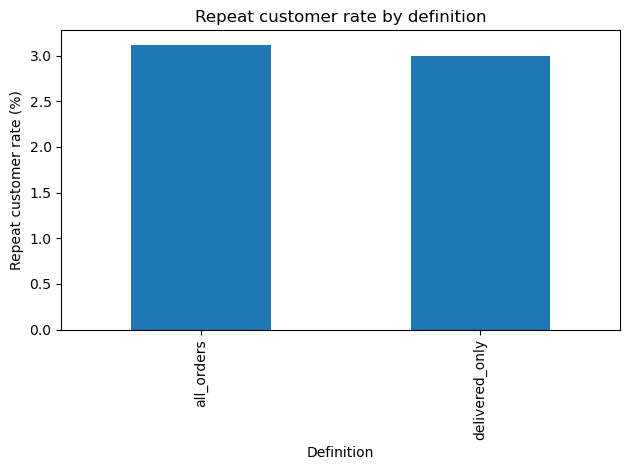

In [18]:
# [1.4-D] 정의 A/B 재구매율 시각화
#
# 힌트:
# kind = "bar"
# x = "definition"
# y = "repeat_customer_rate_pct"

ax = repeat_customer_df.plot(
    kind="bar",
    x="definition",
    y="repeat_customer_rate_pct",
    legend=False
)

ax.set_title("Repeat customer rate by definition")
ax.set_xlabel("Definition")
ax.set_ylabel("Repeat customer rate (%)")
plt.tight_layout()
plt.show()


### 1.4 해석
1. 왜 `customer_id`가 아니라 `customer_unique_id`를 사용해야 하는가?

Olist 데이터셋 특성상 `customer_id`는 주문(Order)이 발생할 때마다 새로 발급되는 (영수증 번호와 같은) 1회성 식별자이다. 반면 `customer_unique_id`는 실제 고객 1명을 특정하는 고유 식별자이다. 한 명의 고객이 재구매하는 행위를 추적하려면 변하지 않는 고유값인 `customer_unique_id`를 기준으로 묶어야 한다.

2. 정의 A/B의 재구매율이 다른 이유는?

집계에 포함된 데이터의 필터링 조건이 다르기 때문이다.
- A(all_orders): 취소되거나 배송 실패한 주문까지 모두 포함한다. 총 96,096명 둥 2,997면(3.12%)이 재구매로 집계되었다.
- B(delivered_only): 실제 고객에게 배송 완료된 유효한 건만 포함한다. 총 93,358명 중 2,801명(3.00%)이 재구매로 집계되었다.

즉 두 번 이상 주문했으나 그중 하나라도 취소 또는 환불하여 최종 배송까지 이어지지 않은 데이터가 `delivered_only`에서는 제외되었기 때문에 모수와 재구매율 모두 낮아진 것이다.

3. 본인은 어떤 정의가 더 적절하다고 보는가?

`delivered_only`가 실질적인 비즈니스 분석에서 적절하다고 생각한다. 결제 직후 변심으로 취소한 건을 재구매로 여기는 것은 지표의 의도가 알맞지 않다.

4. 같은 날 발생한 후속 주문을 재구매로 볼 것인가?

재구매로 보지 않는 것이 타당하다. 결과에 따르면 당일 추가 주문(`days_since_previous_order == 0`)이 961건이다. 이는 고객이 한 번 접속했을 때 깜빡한 물건을 추가 결제했거나 판매자가 달라 장바구니가 분리 결제된 단일 쇼핑일 확률이 크다. 이를 독립적인 재구매로 치면 과대평가될 수 있다.

5. **SQL보다 지표 정의가 먼저**라는 말의 의미는?

코드를 짜는 것 이전에 비즈니스적으로 무엇을 재구매로 인정할 것인지 합의해야 한다는 뜻이다. 당일 결제한 961건을 재구매로 칠 것인지, 배송 완료된 건만 칠 것인지 등의 기준을 명확히 세우지 않으면 실제 비즈니스에 활용된 지표를 결정하기 어렵다. 따라서 목적 정의가 선행되어야 한다.



---

## 1.5 월별 매출 변화 + 카테고리 원인 분해

배송 완료 주문 기준, **2017-01 ~ 2018-08** 분석

### 계산
- 월별 매출
- 전월 매출
- 전월 대비 증감액
- MoM 증감률
- 가장 큰 감소 구간
- 해당 구간의 카테고리별 변화


In [19]:
# [1.5-A] 월별 매출 + LAG
#
# 힌트
# - month = DATE_FORMAT(order_purchase_timestamp, '%Y-%m')
# - revenue = SUM(oi.price)
# - order_count = COUNT(DISTINCT o.order_id)
# - customer_count = COUNT(DISTINCT c.customer_unique_id)
# - delivered만 사용
# - 기간: '2017-01-01' 이상, '2018-09-01' 미만
# - previous_revenue = LAG(revenue) OVER (ORDER BY month)

monthly_sales_sql = """
WITH monthly_sales AS (
    SELECT
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue,
        COUNT(DISTINCT o.order_id) AS order_count,
        COUNT(DISTINCT c.customer_unique_id) AS customer_count

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
      AND o.order_purchase_timestamp <  '2018-09-01'

    GROUP BY DATE_FORMAT(
        o.order_purchase_timestamp,
        '%Y-%m'
    )
),

monthly_with_previous AS (
    SELECT
        month,
        revenue,
        order_count,
        customer_count,
        LAG(revenue) OVER (
            ORDER BY month
        ) AS previous_revenue
    FROM monthly_sales
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    order_count,
    customer_count,
    ROUND(previous_revenue, 2) AS previous_revenue,

    ROUND(
        revenue - previous_revenue,
        2
    ) AS mom_change,

    ROUND(
        100.0 * (revenue - previous_revenue)
        / NULLIF(previous_revenue, 0),
        2
    ) AS growth_rate_pct

FROM monthly_with_previous
ORDER BY month;
"""

monthly_sales_df = run_sql(monthly_sales_sql)
monthly_sales_df


,month,revenue,order_count,customer_count,previous_revenue,mom_change,growth_rate_pct
0,2017-01,111798.36,750,718,NaN,NaN,NaN
1,2017-02,234223.40,1653,1630,111798.36,122425.04,109.51
2,2017-03,359198.85,2546,2508,234223.40,124975.45,53.36
3,2017-04,340669.68,2303,2274,359198.85,-18529.17,-5.16
4,2017-05,489338.25,3546,3479,340669.68,148668.57,43.64
5,2017-06,421923.37,3135,3076,489338.25,-67414.88,-13.78
6,2017-07,481604.52,3872,3802,421923.37,59681.15,14.15
7,2017-08,554699.70,4193,4114,481604.52,73095.18,15.18
8,2017-09,607399.67,4150,4083,554699.70,52699.97,9.50
9,2017-10,648247.65,4478,4417,607399.67,40847.98,6.73


In [20]:
# [1.5-B] 가장 큰 감소 월
#
# 힌트:
# growth_rate_pct가 가장 작은 행을 찾습니다.

worst_idx = monthly_sales_df['growth_rate_pct'].idxmin()
worst_month = monthly_sales_df.loc[worst_idx]

print(worst_month)


month                 2017-12
revenue             726033.19
order_count              5513
customer_count           5450
previous_revenue    987765.37
mom_change         -261732.18
growth_rate_pct         -26.5
Name: 11, dtype: object


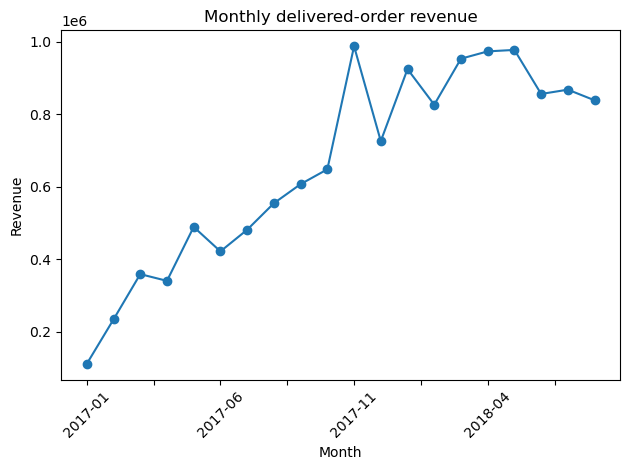

In [21]:
# [1.5-C] 월별 매출 추이
#
# 힌트:
# kind = "line"
# x = "month"
# y = "revenue"

ax = monthly_sales_df.plot(
    kind="line",
    x="month",
    y="revenue",
    marker="o",
    legend=False
)

ax.set_title("Monthly delivered-order revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
# [1.5-D] 2017-11 vs 2017-12 카테고리별 변화
#
# 힌트
# - 카테고리: 번역명이 있으면 영어명, 없으면 원래 카테고리명
# - revenue = SUM(oi.price)
# - delivered만 사용
# - 기간: '2017-11-01' 이상, '2018-01-01' 미만
# - 11월/12월 매출은 conditional aggregation으로 같은 행에 배치
#
# 주의:
# 카테고리별 단순 LAG는 어떤 달의 데이터가 없으면
# '직전 월'이 아닌 '직전에 존재하는 달'을 비교할 수 있습니다.

category_change_sql = """
WITH category_monthly_sales AS (
    SELECT
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ) AS category,

        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_products_dataset AS pr
      ON oi.product_id = pr.product_id
    LEFT JOIN product_category_name_translation AS tr
      ON pr.product_category_name = tr.product_category_name

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-11-01'
      AND o.order_purchase_timestamp <  '2018-01-01'

    GROUP BY
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ),
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        )
),

category_compare AS (
    SELECT
        category,

        SUM(
            CASE
                WHEN month = '2017-11' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_11,

        SUM(
            CASE
                WHEN month = '2017-12' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_12

    FROM category_monthly_sales
    GROUP BY category
)

SELECT
    category,
    ROUND(revenue_2017_11, 2) AS revenue_2017_11,
    ROUND(revenue_2017_12, 2) AS revenue_2017_12,

    ROUND(
        revenue_2017_12 - revenue_2017_11,
        2
    ) AS change_amount

FROM category_compare
ORDER BY change_amount ASC
LIMIT 10;
"""

category_change_df = run_sql(category_change_sql)
category_change_df


,category,revenue_2017_11,revenue_2017_12,change_amount
0,bed_bath_table,87957.63,50081.16,-37876.47
1,computers_accessories,69676.32,37428.67,-32247.65
2,furniture_decor,62091.27,31073.09,-31018.18
3,watches_gifts,95292.34,69556.92,-25735.42
4,cool_stuff,55696.66,37515.57,-18181.09
5,health_beauty,78274.40,60688.75,-17585.65
6,garden_tools,44275.18,26795.69,-17479.49
7,telephony,26117.63,12780.44,-13337.19
8,office_furniture,17919.20,6684.37,-11234.83
9,agro_industry_and_commerce,13932.49,5291.70,-8640.79


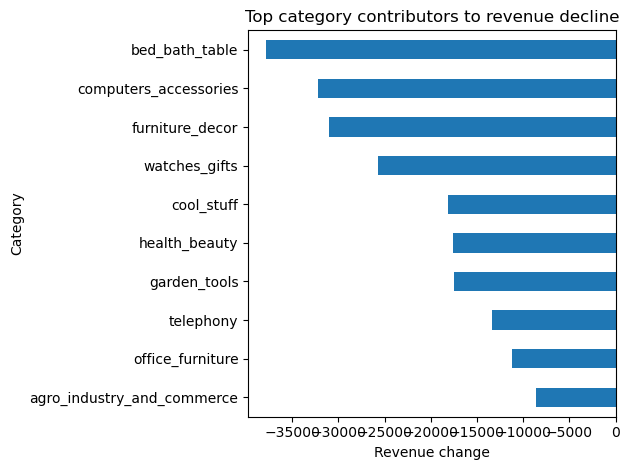

In [26]:
# [1.5-E] 감소 기여 Top 10 그래프
#
# 힌트:
# kind = "barh"
# x = "category"
# y = "change_amount"

plot_df = category_change_df.sort_values(by="change_amount", ascending=False)

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


### 1.5 해석
1. 가장 큰 매출 감소 시점은?

2017년 12월이다. 선 그래프를 보면 11월에 최고점을 찍은 직후 가파르게 하락했다.

2. 감소 폭은?

11월 대비 매출액261,732.18이 감소했으며, 비율로는 -26.5% 감소했다.

3. 감소에 크게 기여한 카테고리는?

하락 폭이 가장 큰 상위 3개 품목은 `bed_bath_table`(-37,876.47), `computers_accessories`(-32,247.65), `furniture_decor`(-31,018.18) 순이다. 이 세 카테고리에서 10만 이상의 매출 감소가 나타났다.

4. 이 결과만으로 실제 **원인**을 확정할 수 있는가?

이 결과만으로는 원인을 특정하기 어렵다.
12월 비즈니스가 실패한 것인지, 아니면 11월 매출(약 98만)이 단기 이벤트로 인해 비정상적으로 튀어 올라 기저효과로 폭락해 보이는 것인지 현재 지표만으로는 판별이 불가능하다.

5. 추가로 필요한 데이터는?

- **11월 프로모션 및 마케팅 내역**: 블랙프라이데이 등 대규모 할인 행사나 광고 단기 집행 여부

- **전년 동기(YoY) 데이터**: 2016년 11-12월 매출 추이와 비교하여 시장의 일반적인 연말 계절성 패턴인지 검증

- **재고 및 배송 지표**: 하락을 주도한 가구 및 인테리어, 침구류 카테고리의 12월 품절률이나 배송 지연에 따른 주문 취소율

- **트래픽 및 전환율**: 12월 접속자(세션) 자체가 감소한 것인지, 트래픽은 유지되었으나 최종 결제 전환율만 무너진 것인지 파악할 퍼널(Funnel)데이터


# 2. 심화 과제 — 아래 중 1개 선택


### A. 배송
배송 지연이 많은 판매자 또는 카테고리 분석

### B. 고객
1회 구매 고객 vs 2회 이상 구매 고객 평균 주문금액 비교

### C. 매출
매출 변화가 큰 시점을 지역 또는 카테고리 관점에서 분해

### D. 자유 분석
상급자에게 보고할 가치가 있는 질문을 직접 정의


In [28]:
# [심화 과제 공통 Skeleton]
#
# 1) 분석 Grain을 먼저 주석으로 적으세요.
# 2) JOIN Key를 먼저 확인하세요.
# 3) 집계 전/후 행 수 검증 쿼리를 최소 1개 포함하세요.
# 4) 핵심 지표를 2개 이상 만드세요.

deep_dive_sql = """
WITH base AS (
    -- 1) 분석 Grain: 고객 거주 지역(customer_state)
    -- 2) JOIN Key:
    --    o.order_id = oi.order_id (주문 - 상세)
    --    o.customer_id = c.customer_id (주문 - 고객)

    SELECT
        c.customer_state,
        DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS month,
        oi.price,
        oi.order_id
    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-11-01'
      AND o.order_purchase_timestamp < '2018-01-01'
),

summary AS (
    SELECT
        customer_state,

        -- 11월, 12월 매출액 분리 (Conditional Aggregation)
        SUM(CASE WHEN month = '2017-11' THEN price ELSE 0 END) AS revenue_11,
        SUM(CASE WHEN month = '2017-12' THEN price ELSE 0 END) AS revenue_12,

        -- 11월, 12월 주문 상품 수 분리
        COUNT(CASE WHEN month = '2017-11' THEN order_id END) AS items_11,
        COUNT(CASE WHEN month = '2017-12' THEN order_id END) AS items_12

    FROM base
    GROUP BY customer_state
)

SELECT
    customer_state,
    ROUND(revenue_11, 2) AS revenue_11,
    ROUND(revenue_12, 2) AS revenue_12,

    -- 4) 핵심 지표 1: 매출 증감액 (Absolute Change)
    ROUND(revenue_12 - revenue_11, 2) AS revenue_change_amount,

    -- 4) 핵심 지표 2: 매출 증감률 (Percentage Change)
    ROUND(
        100.0 * (revenue_12 - revenue_11) / NULLIF(revenue_11, 0),
        2
    ) AS revenue_change_pct,

    -- 4) 핵심 지표 3: 판매 상품 수 증감
    items_12 - items_11 AS item_change_count

FROM summary
ORDER BY revenue_change_amount ASC
LIMIT 10;
"""

deep_dive_df = run_sql(deep_dive_sql)
deep_dive_df.head(10)


,customer_state,revenue_11,revenue_12,revenue_change_amount,revenue_change_pct,item_change_count
0,SP,350790.18,274951.74,-75838.44,-21.62,-753
1,MG,132686.09,91152.90,-41533.19,-31.30,-306
2,RJ,147782.40,112259.63,-35522.77,-24.04,-349
3,PR,45751.34,29894.54,-15856.80,-34.66,-160
4,RS,57463.27,41904.95,-15558.32,-27.08,-160
5,SC,37870.90,24234.89,-13636.01,-36.01,-132
6,ES,23858.76,12189.76,-11669.00,-48.91,-81
7,DF,26406.16,16829.68,-9576.48,-36.27,-21
8,CE,18353.59,10299.44,-8054.15,-43.88,-35
9,GO,20726.21,15674.93,-5051.28,-24.37,-44


### 심화 과제 작성
- 분석 질문: 2017년 11월 대비 12월의 매출 폭락은 어느 지역(State)에서 주로 발생했는가?
- 분석 Grain: 고객 거주 주(cutomer_state)
- 사용 테이블: `olist_orders_dataset`, `olist_order_items_dataset`, `olist_customers_dataset`
- JOIN Key:

  - `o.order_id = oi.order_id` (주문 - 주문 상세)
  - `o.customer_id = c.customer_id` (주문 - 고객)

- 지표 / 파생변수:

  - 월별 매출 (`revenue_11`, `revenue_12`)

  - 매출 증감액 (`revenue_change_amount`)

  - 매출 증감률 (`revenue_change_pct`)

  - 월별 판매 상품 수 증감 (`item_change_count`)

- 필터 기준:

  - `order_status = 'delivered'` (배송 완료건)

  - `order_purchase_timestamp` 기준 2017년 11월 1일 이상 ~ 2018년 1 1일 미만

- 검증 방법: 필터링된 원본 Base 테이블의 전체 아이템 행 수(COUNT)와 Summary 테이블에서 집계한 11월, 12월 상품 수의 총합(`items_11` + `items_12`)이 정확히 일치하는지 대조하여 JOIN 과정에서의 데이터 부풀려짐이나 누락을 확인한다.

- 핵심 숫자 2~3개:

  - -75,838.44: 1위 SP 지역의 단일 매출 감소액으로, 하위 여러 주의 감소액을 합친 것보다 큽니다.

  - -48.91%: ES 지역의 전월 대비 매출 감소율로, 12월 매출이 11월 대비 반토막 났음을 보여줍니다.

  - -349건: 핵심 상권 중 하나인 RJ에서 증발한 판매 상품 건수입니다.

- 해석: 매출 감소는 소수의 특정 지역 이슈가 아니라 플랫폼 전반을 대상으로 한 거시적 현상이다. 브라질의 핵심 경제권인 상파울루(SP), 미나스제라이스(MG), 리우데자네이루(RJ) Top 3 지역에서 약 15만 달러 이상의 절대적 매출 감소가 발생했다. 하지만 이 지역들은 원래 플랫폼 내 파이가 가장 큰 상권이므로 하락장에서 절대적인 타격액 1위를 차지할 수밖에 없는 구조적 한계가 있다. 따라서 지역 내 비즈니스 타격 심각도(비율)를 함께 살펴보면, ES(-48.91%)와 CE(-43.88%) 지역의 매출이 전월 대비 거의 반토막 수준으로 가장 취약한 모습을 보였다. 상위 10개 주 모두 21~48%의 심각한 마이너스 성장을 기록한 것으로 보아, 이는 12월 자체의 비즈니스 실패라기보다는 11월 블랙프라이데이 등 대규모 프로모션으로 인한 과도한 수요 선점이 12월의 구매 절벽으로 이어졌을 확률이 매우 높음을 시사한다.

- 한계 / 추가 분석:

  - 한계: 현재 지표는 '결과적인 하락'만 보여줄 뿐, 고객이 사이트에 오지 않은 것인지(트래픽 감소), 왔는데 안 산 것인지(전환율 하락)를 구분할 수 없다.

  - 추가 분석: 11월 프로모션 할인율 혜택이 Top 3 지역(SP, MG, RJ)에 편중되었는지 마케팅 데이터를 교차 검증해야 한다. 또한, 11월 폭증한 물동량으로 인해 12월에 배송 지연이나 CS 클레임이 폭증하여 구매 취소율이 높아졌는지 '주문-배송 소요일(lead time)' 데이터를 추가로 뜯어봐야 정확한 인과관계를 밝힐 수 있을 것이다.


#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: 조인 조건을 `c.customer_id = c.customer_id`로 잘못 적어 카테시안 곱이 발생하거나, 상품 테이블에 없는 `order_id`로 조인을 시도하는 등 ERD 구조를 제대로 파악하지 못해 에러를 겪었다. 파이썬에서는 데이터프레임 컬럼명에 따옴표를 누락해 기초적인 변수 참조 에러를 내기도 했다.

코드를 스스로 재검토하며 테이블 간 정확한 PK/FK(`product_id` 등) 매핑을 확인하고 코드 문법을 교정하여 해결했다. 끝까지 헷갈린 개념은 비즈니스 지표 산출 시 고유 계정(`customer_unique_id`)과 1회성 주문 번호(`customer_id`)를 구분하는 기준과, `SUM(CASE WHEN...)` 형태의 조건부 집계(Conditional Aggregation)를 활용하는 로직이었다.

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: 지역(State) 단위로 분석 Grain을 쪼개어 데이터를 분해하면서, 쿼리부터 치는 것이 아니라 '분석 목적'과 집계 전후의 '행 수 검증(Sanity Check)'을 먼저 설계하는 스켈레톤(Skeleton) 접근법의 중요성을 배웠다.

단순한 매출 폭락 수치(-26.5%) 이면에 존재하는 11월 블랙프라이데이 수요 선점(기저효과)이나 트래픽 변동 등 비즈니스적 한계를 같이 짚어내야 실무적인 데이터 분석이 될 수 있음을 깨달았다..

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로):

1. 처음에 기본 런타임으로 설정하여 코드를 돌리기 시작했는데, 코드가 돌아가지 않았다. 로컬 런타임을 써야함을 깨닫고 그 방법을 Gemini에게 질문하였다.

2. 디버깅: 심화 과제를 수행할 때 `SELECT`가 누락되는 경우가 있었다. Gemini에게 내가 직접 작성한 코드를 제시하고 코드의 문제점을 질문한 후 답변에 따라 디버깅하였다.

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: AI에게 받은 답변을 적용하여 직접 실행하고 결과를 확인하였다.

- **실제 대화 내역** 붙여넣기:


1.

```
> 나: (코드 제시)
  해당 코드의 어느 부분이 틀린 건가요?
```

```
< Gemini: 두 번째 CTE인 summary 안에 SELECT 키워드가 빠졌습니다.

SELECT 없이 바로 customer_state부터 작성하셔서 SQL 문법 에러가 발생한 겁니다. 누락된 SELECT를 추가한 수정 코드입니다.

(Gemini 코드 제시)
```

2.
  ```
  > 나: (에러 메시지 제시)
  구글 colab 환경에서 코드를 실행하고 있는데 해당 에러가 발생하였습니다. 해결책을 자세히 제시해주세요.
  ```

  ```
  < Gemini: 정확한 진행 순서는 다음과 같습니다.

1
PC에 Jupyter 서버 실행
cmd/PowerShell
컴퓨터의 터미널(명령 프롬프트나 PowerShell)을 열고 jupyter notebook 명령어를 입력해 실행합니다. (PC에 파이썬과 Jupyter가 설치되어 있어야 합니다.)

2
로컬 주소(URL) 복사
서버가 켜지면 터미널 창에 http://localhost:8888/?token=어쩌구저쩌구... 형태의 긴 주소가 출력됩니다. 이것이 해당 안내문에서 요구하는 URL입니다. 이 주소를 그대로 복사합니다.

3
코랩에 URL 입력
열어두신 코랩 우측 상단의 '연결' 버튼(또는 RAM/디스크 아이콘) 옆 화살표를 누르고 **'로컬 런타임에 연결'**을 클릭합니다. 복사한 URL을 붙여넣고 연결을 마칩니다.

연결이 성공하면 코랩 우측 상단 상태창에 '로컬'이라고 표시됩니다. 이제 코랩에서 파이썬 코드를 돌려도 실제로는 개인 PC에서 실행되는 것이므로, 드디어 127.0.0.1을 통해 개인 컴퓨터에 켜져 있는 MySQL에 접속할 수 있습니다.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? 심화 과제 분석 질문 설정